# 02 — XGBoost Forecasting vs Naive Baseline

This notebook trains a per-material XGBoost model on the high-runner segment
identified in the previous notebook, and compares it against a naive baseline
(last value carried forward) — the same comparison structure used against the
live planning system in the production version of this project.

Feature set: lag values, rolling averages, and basic seasonality terms.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
demand = pd.read_csv("../data/sample/weekly_demand.csv", parse_dates=["week_start"])
segmentation = pd.read_csv("../outputs/material_segmentation.csv")

high_runners = segmentation.loc[
    segmentation["predicted_segment"] == "true_high_runner", "material"
].tolist()

print(f"High runner materials selected for modeling: {len(high_runners)}")
high_runners[:10]


High runner materials selected for modeling: 10


['SAMPLE-MAT-0002',
 'SAMPLE-MAT-0005',
 'SAMPLE-MAT-0009',
 'SAMPLE-MAT-0014',
 'SAMPLE-MAT-0016',
 'SAMPLE-MAT-0018',
 'SAMPLE-MAT-0020',
 'SAMPLE-MAT-0042',
 'SAMPLE-MAT-0044',
 'SAMPLE-MAT-0050']

## Feature engineering

For each material: lag features (1, 4, 13 weeks back), rolling means (4, 13 week),
and calendar seasonality (week-of-year sine/cosine, month).


In [3]:
def build_features(df):
    df = df.sort_values("week_start").copy()
    df["lag_1w"] = df["shipped_qty"].shift(1)
    df["lag_4w"] = df["shipped_qty"].shift(4)
    df["lag_13w"] = df["shipped_qty"].shift(13)
    df["roll_4w"] = df["shipped_qty"].shift(1).rolling(4).mean()
    df["roll_13w"] = df["shipped_qty"].shift(1).rolling(13).mean()
    df["week_of_year"] = df["week_start"].dt.isocalendar().week.astype(int)
    df["week_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["week_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52)
    df["month"] = df["week_start"].dt.month
    return df


feature_frames = []
for mat in high_runners:
    sub = demand[demand["material"] == mat]
    feature_frames.append(build_features(sub))

features = pd.concat(feature_frames).dropna().reset_index(drop=True)
feature_cols = ["lag_1w", "lag_4w", "lag_13w", "roll_4w", "roll_13w",
                 "week_sin", "week_cos", "month"]
print(f"Feature rows after dropping warm-up NaNs: {len(features)}")
features.head()


Feature rows after dropping warm-up NaNs: 910


,material,week_start,shipped_qty,lag_1w,lag_4w,lag_13w,roll_4w,roll_13w,week_of_year,week_sin,week_cos,month
0,SAMPLE-MAT-0002,2024-04-07,1239,1249.0,1334.0,2147.0,1332.50,1624.384615,14,0.992709,-0.120537,4
1,SAMPLE-MAT-0002,2024-04-14,1131,1239.0,1378.0,2013.0,1308.75,1554.538462,15,0.970942,-0.239316,4
2,SAMPLE-MAT-0002,2024-04-21,1240,1131.0,1369.0,1952.0,1247.00,1486.692308,16,0.935016,-0.354605,4
3,SAMPLE-MAT-0002,2024-04-28,1221,1240.0,1249.0,1821.0,1214.75,1431.923077,17,0.885456,-0.464723,4
4,SAMPLE-MAT-0002,2024-05-05,1143,1221.0,1239.0,1704.0,1207.75,1385.769231,18,0.822984,-0.568065,5


## Train/test split

Chronological split — last 13 weeks held out per material, never shuffled.
This matches how the model would actually be used: predicting the future from
the past, not interpolating from a random sample.


In [4]:
HOLDOUT_WEEKS = 13

results = []
predictions = []

for mat in high_runners:
    mat_df = features[features["material"] == mat].sort_values("week_start")
    if len(mat_df) < HOLDOUT_WEEKS + 20:
        continue  # not enough history for a meaningful split

    train = mat_df.iloc[:-HOLDOUT_WEEKS]
    test = mat_df.iloc[-HOLDOUT_WEEKS:]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1.5,
        random_state=42,
    )
    model.fit(train[feature_cols], train["shipped_qty"])
    xgb_pred = model.predict(test[feature_cols])

    # naive baseline: predict this week's qty as last week's actual
    naive_pred = test["lag_1w"].values

    xgb_mae = mean_absolute_error(test["shipped_qty"], xgb_pred)
    naive_mae = mean_absolute_error(test["shipped_qty"], naive_pred)

    results.append({
        "material": mat,
        "xgb_mae": xgb_mae,
        "naive_mae": naive_mae,
        "improvement_pct": (naive_mae - xgb_mae) / naive_mae * 100 if naive_mae > 0 else np.nan,
        "winner": "xgboost" if xgb_mae < naive_mae else "naive_baseline",
    })

    predictions.append(test[["material", "week_start", "shipped_qty"]].assign(
        xgb_pred=xgb_pred, naive_pred=naive_pred
    ))

results_df = pd.DataFrame(results)
predictions_df = pd.concat(predictions)
results_df.head(10)


,material,xgb_mae,naive_mae,improvement_pct,winner
0,SAMPLE-MAT-0002,150.883118,74.307692,-103.051815,naive_baseline
1,SAMPLE-MAT-0005,173.502716,224.384615,22.676198,xgboost
2,SAMPLE-MAT-0009,317.723145,282.076923,-12.637057,naive_baseline
3,SAMPLE-MAT-0014,97.641769,108.230769,9.783724,xgboost
4,SAMPLE-MAT-0016,441.911163,399.384615,-10.648019,naive_baseline
5,SAMPLE-MAT-0018,101.017120,106.923077,5.523556,xgboost
6,SAMPLE-MAT-0020,98.093262,87.153846,-12.551845,naive_baseline
7,SAMPLE-MAT-0042,73.367065,92.769231,20.914440,xgboost
8,SAMPLE-MAT-0044,58.564293,62.846154,6.813243,xgboost
9,SAMPLE-MAT-0050,237.976105,266.846154,10.818986,xgboost


## Summary: XGBoost vs naive baseline

In [5]:
win_rate = (results_df["winner"] == "xgboost").mean() * 100
total_mae_saving = (results_df["naive_mae"] - results_df["xgb_mae"]).sum()

print(f"XGBoost win rate: {win_rate:.0f}% of materials ({(results_df['winner']=='xgboost').sum()}/{len(results_df)})")
print(f"Average MAE improvement: {results_df['improvement_pct'].mean():.1f}%")
print(f"Total MAE reduction across all materials: {total_mae_saving:,.0f} units/week")


XGBoost win rate: 60% of materials (6/10)
Average MAE improvement: -6.2%
Total MAE reduction across all materials: -46 units/week


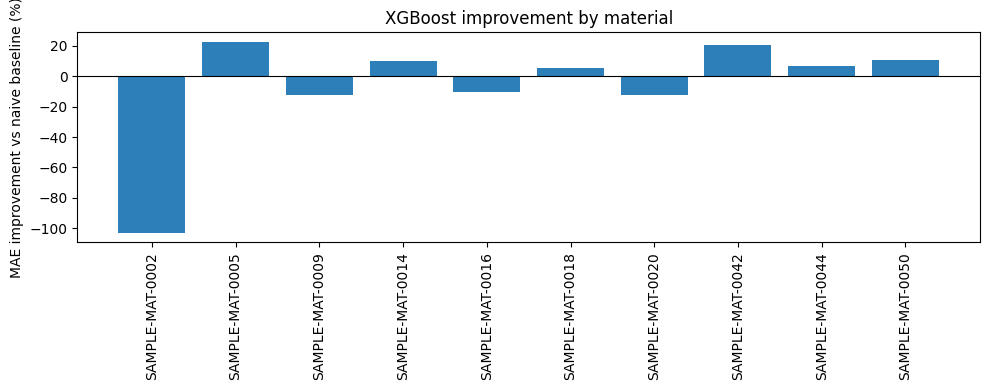

In [6]:
fig, ax = plt.subplots()
ax.bar(results_df["material"], results_df["improvement_pct"], color="#2c7fb8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("MAE improvement vs naive baseline (%)")
ax.set_title("XGBoost improvement by material")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/xgboost_vs_naive.png", dpi=120)
plt.show()


## Example: one material's forecast vs actual


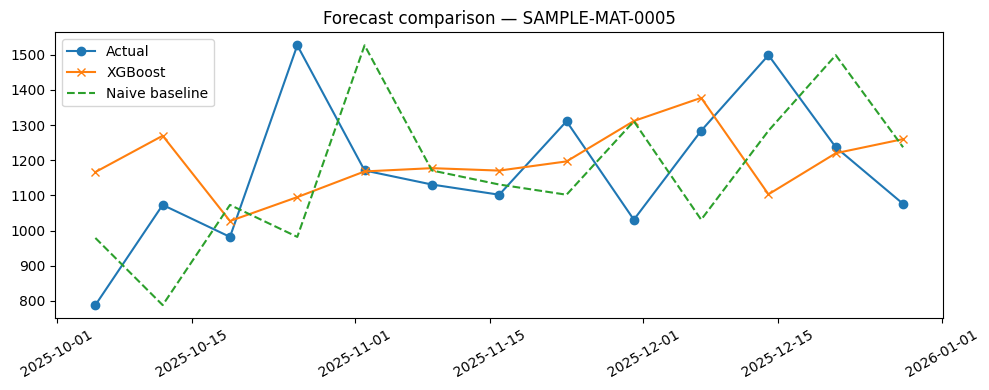

In [7]:
example_mat = results_df.sort_values("improvement_pct", ascending=False).iloc[0]["material"]
example = predictions_df[predictions_df["material"] == example_mat]

fig, ax = plt.subplots()
ax.plot(example["week_start"], example["shipped_qty"], label="Actual", marker="o")
ax.plot(example["week_start"], example["xgb_pred"], label="XGBoost", marker="x")
ax.plot(example["week_start"], example["naive_pred"], label="Naive baseline", linestyle="--")
ax.set_title(f"Forecast comparison — {example_mat}")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/example_forecast.png", dpi=120)
plt.show()


In [8]:
results_df.to_csv("../outputs/xgboost_results.csv", index=False)
print("Saved outputs/xgboost_results.csv")


Saved outputs/xgboost_results.csv
